# 22 — CellCast, another approach

- Want to try another approach? GPU problems? scikit-ops a disaster?
- Try CellCast: A rust implementation of deep learning models which includes StarDist's pretrained fluorescence model, without TensorFlow. Installs with pip, runs in the host.

## Add it

From the `pixi` folder of the repo:

```sh
cd i2k-2026/pixi
pixi add --pypi cellcast
```

Then restart the kernel.

## Load the sample image

(768, 768) float32


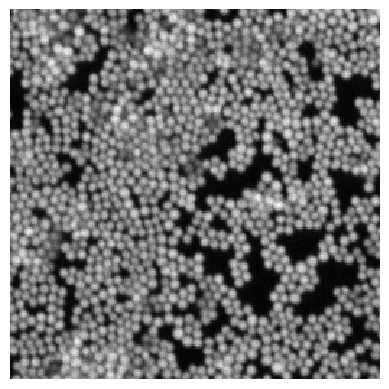

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
from skimage.io import imread
from tnia.plotting.plt_helper import mask_outline_overlay

im = imread(Path('data') / 'stardist_cellcast' / 's_aureus_stat.tif')
print(im.shape, im.dtype)

plt.imshow(im, cmap='gray')
plt.axis('off');

## Run CellCast

In [5]:
import cellcast

model = cellcast.models.StarDist2D.init_fluo(gpu=True)
cellcast_labels = model.predict_fluo(im, prob_threshold=0.5, nms_threshold=0.3)
print('CellCast:', cellcast_labels.max(), 'objects')

CellCast: 1183 objects


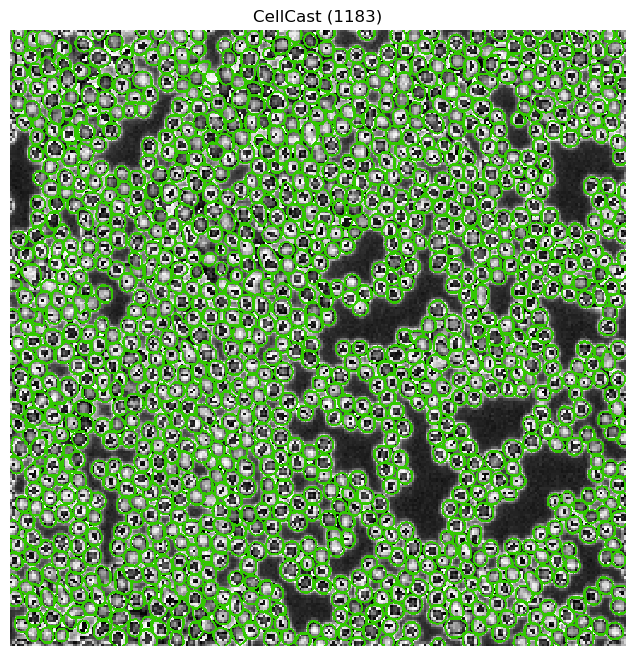

In [8]:
plt.figure(figsize=(8, 8))
plt.imshow(mask_outline_overlay(im.astype('uint8'), cellcast_labels, color=[50, 200, 0], thickness=2))
plt.title(f'CellCast ({cellcast_labels.max()})')
plt.axis('off');

## Compare with scikit-ops StarDist

If scikit-ops works for you.  Try them both and see if they are the same. |

In [7]:
from skop.runner import Runner
from skop.ops.segment.stardist2d import stardist2d_fluo

runner = Runner()
stardist_labels = runner.run(stardist2d_fluo, image=im, prob_thresh=0.5, nms_thresh=0.3)
print('scikit-ops StarDist:', stardist_labels.max(), 'objects')

scikit-ops StarDist: 1182 objects


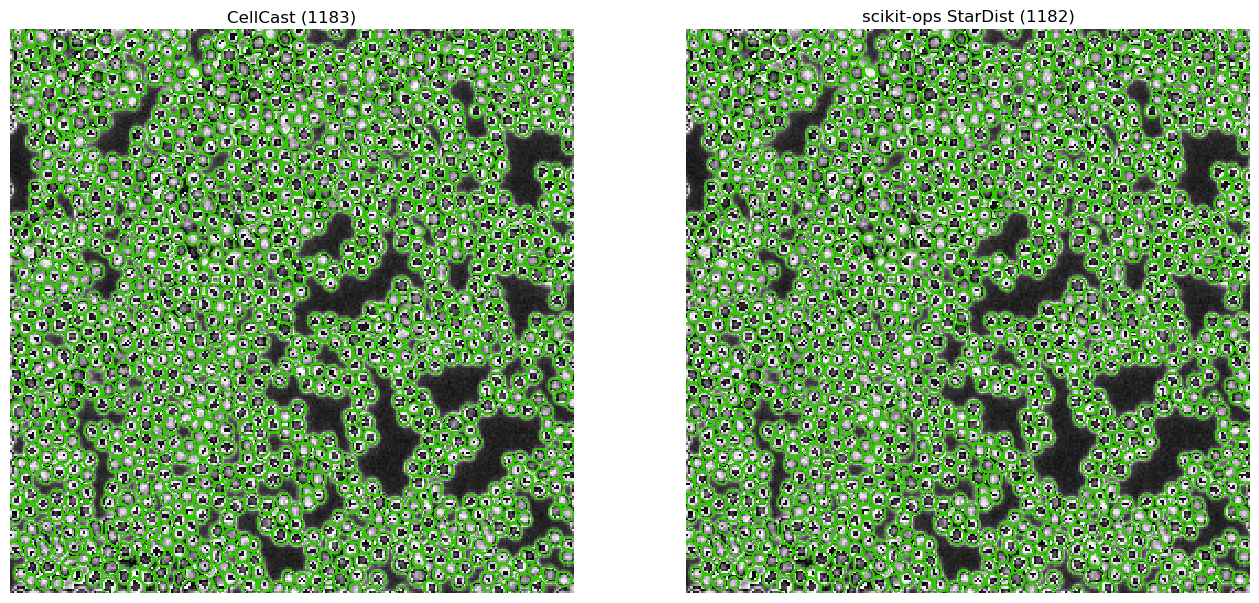

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(mask_outline_overlay(im.astype('uint8'), cellcast_labels, color=[50, 200, 0], thickness=2))
axes[0].set_title(f'CellCast ({cellcast_labels.max()})')

axes[1].imshow(mask_outline_overlay(im.astype('uint8'), stardist_labels, color=[50, 200, 0], thickness=2))
axes[1].set_title(f'scikit-ops StarDist ({stardist_labels.max()})')

for ax in axes:
    ax.axis('off')

In [10]:
runner.release()